# 花卉数据集图像分类（CNN，PyTorch）

本 notebook 读取 `DataSets/flower_data` 下的花卉图片数据，完成：

- 数据读取与预处理（训练/验证/测试划分、数据增强、归一化）
- 搭建基于卷积神经网络（CNN）的分类模型并训练
- 输出训练结果并可视化（Loss/Accuracy 曲线、预测效果图）

> 数据集目录结构（`ImageFolder` 约定）：
>
> ```
> DataSets/flower_data/
>   daisy/
>   dandelion/
>   roses/
>   sunflowers/
>   tulips/
> ```

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 让实验可复现
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)

device: cuda
torch: 2.8.0+cu129


## 1. 读取数据集与数据预处理

我们使用 `torchvision.datasets.ImageFolder` 直接从文件夹读取图片。

- **数据增强（train）**：随机裁剪/翻转/轻微颜色抖动，提升泛化
- **验证/测试（val/test）**：只做 Resize + CenterCrop，保持评估稳定
- **归一化**：使用 ImageNet 的 mean/std（通用且常用）

同时把全量数据集按比例划分为：train/val/test。

In [3]:
# 数据目录
DATA_DIR = Path("../DataSets/flower_data")
assert DATA_DIR.exists(), f"找不到数据目录: {DATA_DIR.resolve()}"

# 超参数（可按需改）
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows 上设为 0 更稳

# ImageNet 归一化
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# 先用“无增强”的 transform 构建一个基准 dataset，用于划分与类别读取
base_ds = datasets.ImageFolder(root=str(DATA_DIR), transform=test_tfms)
class_names = base_ds.classes
num_classes = len(class_names)

print("num_classes:", num_classes)
print("classes:", class_names)
print("total images:", len(base_ds))

# 按比例划分
train_ratio, val_ratio, test_ratio = 0.8, 0.2, 0
n_total = len(base_ds)
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    base_ds,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

# 重要：给 train 子集换成带增强的 transform
train_ds.dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_tfms)
val_ds.dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=test_tfms)
test_ds.dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("split sizes:", len(train_ds), len(val_ds), len(test_ds))

num_classes: 5
classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
total images: 3670
split sizes: 2936 734 0


## 2. 可视化：看几张增强后的训练样本

为了确认数据读取与增强没问题，我们从 `train_loader` 抽取一个 batch，把归一化后的张量反归一化并显示。

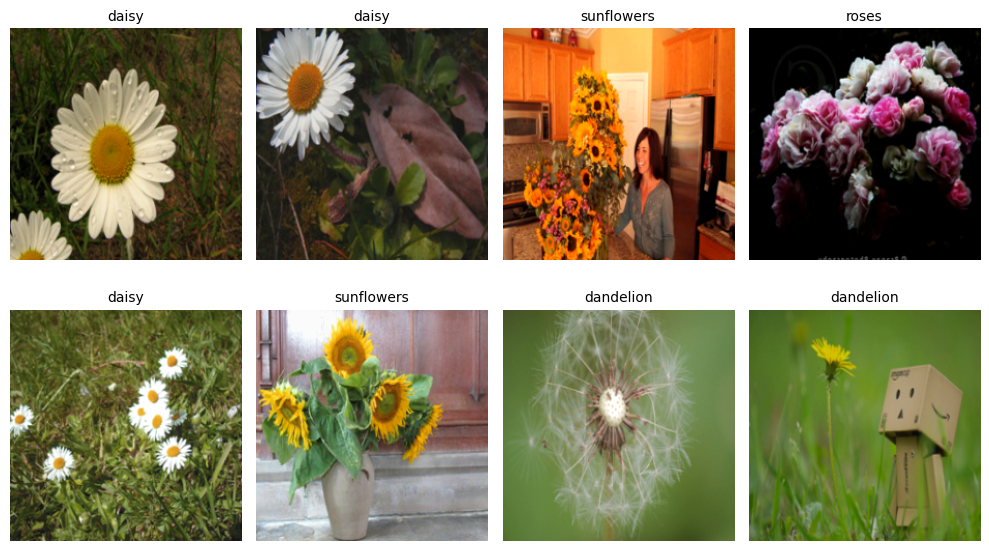

In [4]:
def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    x = img_tensor.detach().cpu() * std + mean
    return x.clamp(0, 1)

batch_imgs, batch_labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
show_n = min(8, batch_imgs.size(0))
for i in range(show_n):
    plt.subplot(2, 4, i + 1)
    img = denormalize(batch_imgs[i])
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[int(batch_labels[i])], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. 搭建 CNN 模型

这里实现一个轻量 CNN：多层卷积 + BatchNorm + ReLU + 池化，最后用全局平均池化（`AdaptiveAvgPool2d`）接全连接分类。

如果你后续希望更高精度，也可以替换成 `torchvision.models` 的预训练网络（如 ResNet18），但本任务先用“从零搭建”的 CNN 更直观。

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=num_classes).to(device)
print(model)

# 计算参数量
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {num_params/1e6:.2f}M")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

## 4. 训练与验证

训练时记录每个 epoch 的：

- **train loss / train acc**
- **val loss / val acc**

并在验证集上保存表现最好的模型权重（以 `val acc` 为准）。

In [6]:
from dataclasses import dataclass

@dataclass
class EpochStats:
    loss: float
    acc: float

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return EpochStats(loss=total_loss / total, acc=total_correct / total)


def train(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total += x.size(0)

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        val_stats = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_stats.loss)
        history["val_acc"].append(val_stats.acc)

        if val_stats.acc > best_val_acc:
            best_val_acc = val_stats.acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_stats.loss:.4f} acc {val_stats.acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

EPOCHS = 70
LR = 1e-3

history = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 01/70 | train loss 1.2221 acc 0.4942 | val loss 1.0118 acc 0.5981
Epoch 02/70 | train loss 1.1029 acc 0.5668 | val loss 0.9260 acc 0.6390
Epoch 03/70 | train loss 1.0184 acc 0.6090 | val loss 0.9752 acc 0.6499
Epoch 04/70 | train loss 0.9845 acc 0.6165 | val loss 1.0278 acc 0.6444
Epoch 05/70 | train loss 0.9271 acc 0.6417 | val loss 0.9746 acc 0.6621
Epoch 06/70 | train loss 0.8923 acc 0.6594 | val loss 0.8184 acc 0.6662
Epoch 07/70 | train loss 0.8812 acc 0.6642 | val loss 0.9037 acc 0.6540
Epoch 08/70 | train loss 0.8414 acc 0.6866 | val loss 0.8538 acc 0.6839
Epoch 09/70 | train loss 0.8221 acc 0.6945 | val loss 0.7481 acc 0.7221
Epoch 10/70 | train loss 0.8021 acc 0.7047 | val loss 0.9764 acc 0.6798
Epoch 11/70 | train loss 0.7811 acc 0.7040 | val loss 0.9235 acc 0.6689
Epoch 12/70 | train loss 0.7804 acc 0.7119 | val loss 0.7159 acc 0.7439
Epoch 13/70 | train loss 0.7694 acc 0.7125 | val loss 0.7166 acc 0.7153
Epoch 14/70 | train loss 0.7257 acc 0.7330 | val loss 0.7615 acc

## 5. 训练曲线可视化（Accuracy / Loss）

绘制 train/val 的准确率与损失曲线，直观看训练是否收敛、是否过拟合。

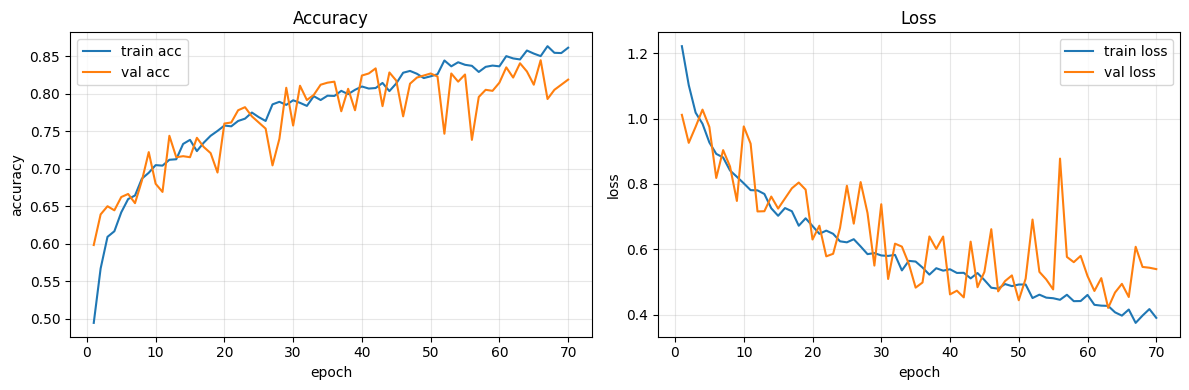

In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 6. 在测试集上评估

使用训练过程中“验证集表现最好”的模型权重，在测试集上计算最终准确率。

In [9]:
criterion = nn.CrossEntropyLoss()
test_stats = evaluate(model, test_loader, criterion)
print(f"test loss: {test_stats.loss:.4f}")
print(f"test acc : {test_stats.acc:.4f}")

ZeroDivisionError: float division by zero

## 7. 预测效果可视化

从测试集随机取一些图片，展示：

- **真实标签（GT）**
- **预测标签（Pred）**
- **预测置信度（Softmax 概率）**

并用颜色区分预测对/错。

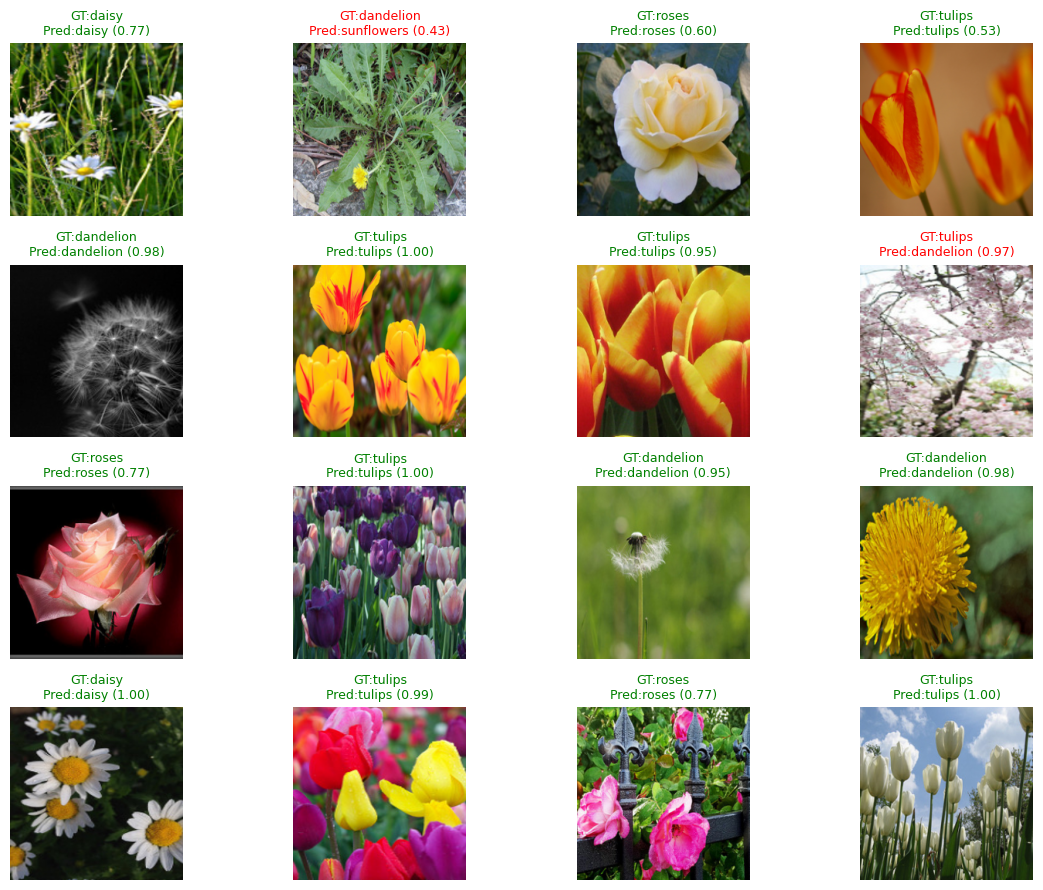

In [19]:
import torch.nn.functional as F

@torch.no_grad()
def collect_predictions(model, loader, max_items=32):
    model.eval()
    xs, ys, ps, confs = [], [], [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        prob = F.softmax(logits, dim=1)
        conf, pred = prob.max(dim=1)

        xs.append(x.cpu())
        ys.append(y.cpu())
        ps.append(pred.cpu())
        confs.append(conf.cpu())

        if sum(t.size(0) for t in xs) >= max_items:
            break

    x_all = torch.cat(xs, dim=0)[:max_items]
    y_all = torch.cat(ys, dim=0)[:max_items]
    p_all = torch.cat(ps, dim=0)[:max_items]
    c_all = torch.cat(confs, dim=0)[:max_items]
    return x_all, y_all, p_all, c_all

x_vis, y_vis, p_vis, c_vis = collect_predictions(model, test_loader, max_items=16)

plt.figure(figsize=(12, 9))
for i in range(len(x_vis)):
    plt.subplot(4, 4, i + 1)
    img = denormalize(x_vis[i])
    plt.imshow(img.permute(1, 2, 0))

    gt = class_names[int(y_vis[i])]
    pr = class_names[int(p_vis[i])]
    ok = int(y_vis[i]) == int(p_vis[i])

    title = f"GT:{gt}\nPred:{pr} ({float(c_vis[i]):.2f})"
    plt.title(title, fontsize=9, color=("green" if ok else "red"))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8.（可选）保存模型

把训练好的模型权重保存到本地，方便后续推理或继续训练。

In [20]:
SAVE_PATH = Path("class5/simple_cnn_flower_0.84.pth")
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "img_size": IMG_SIZE,
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD,
    },
    str(SAVE_PATH),
)
print("saved to:", SAVE_PATH.resolve())

saved to: D:\Codes\CV_Lib\class5\class5\simple_cnn_flower_0.84.pth
